# Deep Learning
MATH 70116<br>
Autumn 2026<br>
Lecturer: Tom Hadfield

## Implementing Neural Networks in Pytorch

which Python am I running?

In [1]:
import sys
print(sys.executable)

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260618\PatnaikPearson\ml_env311_20260618\Scripts\python.exe


First we import <b>Pytorch</b>

In [2]:
import torch

Second, for later use we import <b>NumPy</b> and <b>matplotlib</b> (and set a nicer plotting style).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

We now specify a feedforward neural network with, for example,  $r=3$, $I=d_0=2$, $d_1=100$, $d_2=100$, $O=d_3=1$, $\sigma_1(x)=\sigma_2(x)=\mathrm{ReLU}(x)=\max(x,0)$, $\sigma_3(x)=x$ as follows. A shorthand notation that we will use for such a network is
$$
f \in \mathcal{N}_3(2,100,100,1;\mathrm{ReLU},\mathrm{ReLU},\mathrm{Id}).
$$

Specifying such a neural network can be done using ..

In [4]:
import torch.nn as nn

f = nn.Sequential(
    nn.Linear(2, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

An alternative, but equivalent, way of doing the same using the <code>add_module</code> method is:

In [5]:
f = nn.Sequential()
f.add_module("dense1", nn.Linear(2, 100))
f.add_module("relu1", nn.ReLU())
f.add_module("dense2", nn.Linear(100, 100))
f.add_module("relu2", nn.ReLU())
f.add_module("dense3", nn.Linear(100, 1))

Visualising the network:

1. Basic

In [6]:
print(f)

Sequential(
  (dense1): Linear(in_features=2, out_features=100, bias=True)
  (relu1): ReLU()
  (dense2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (dense3): Linear(in_features=100, out_features=1, bias=True)
)


2. Manual parameter count

In [7]:
total_params = sum(p.numel() for p in f.parameters())
trainable_params = sum(p.numel() for p in f.parameters() if p.requires_grad)
print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

Total params: 10501
Trainable params: 10501


In [8]:
for p in f.parameters():
    print(type(p), p.shape, p.requires_grad)

<class 'torch.nn.parameter.Parameter'> torch.Size([100, 2]) True
<class 'torch.nn.parameter.Parameter'> torch.Size([100]) True
<class 'torch.nn.parameter.Parameter'> torch.Size([100, 100]) True
<class 'torch.nn.parameter.Parameter'> torch.Size([100]) True
<class 'torch.nn.parameter.Parameter'> torch.Size([1, 100]) True
<class 'torch.nn.parameter.Parameter'> torch.Size([1]) True


Remove the final layer of the model:

In [9]:
print(f)

Sequential(
  (dense1): Linear(in_features=2, out_features=100, bias=True)
  (relu1): ReLU()
  (dense2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (dense3): Linear(in_features=100, out_features=1, bias=True)
)


In [10]:
del f.dense3

In [11]:
print(f)

Sequential(
  (dense1): Linear(in_features=2, out_features=100, bias=True)
  (relu1): ReLU()
  (dense2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
)


Add back in the deleted layer:

In [12]:
f.add_module("dense3", nn.Linear(100, 1))

In [13]:
print(f)

Sequential(
  (dense1): Linear(in_features=2, out_features=100, bias=True)
  (relu1): ReLU()
  (dense2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (dense3): Linear(in_features=100, out_features=1, bias=True)
)


Extract a named layer and inspect it:

In [14]:
layer = f.get_submodule("dense1")

weights = layer.weight   # shape: (out_features, in_features)
bias = layer.bias        # shape: (out_features,)

print(weights.shape)
print(bias.shape)

# As plain numpy arrays (detached from autograd graph)
weights_np = layer.weight.detach().numpy()
bias_np = layer.bias.detach().numpy()

print(type(weights_np), weights_np.shape)
print(type(bias_np), bias_np.shape)

torch.Size([100, 2])
torch.Size([100])
<class 'numpy.ndarray'> (100, 2)
<class 'numpy.ndarray'> (100,)


We have not trained $f$ yet, so $W^1 \in \mathbb{R}^{100 \times 2}$ and $\boldsymbol{b}^1 \in \mathbb{R}^{100}$ are at their initialiser values. By default, when you create a Pytorch  model, the weights are initialized using default strategies. 

PyTorch's defaults depend on the layer type. For <code>nn.Linear</code> 
weights and biases are both drawn from a uniform distribution:
$$W_{ij},\ b_i \sim \mathcal{U}\!\left(-\tfrac{1}{\sqrt{\text{fan\_in}}},\ +\tfrac{1}{\sqrt{\text{fan\_in}}}\right)$$
where `fan_in` is the layer's `in_features`. For `nn.Linear(2, 100)`, `fan_in = 2`, so the bounds are $\pm 1/\sqrt{2}$.

Sanity check: If $X \sim \mathcal{U} [a,b]$, then $\mathbb{E}(X) = {\frac{1}{2}}(a+b)$ 
and $\sigma(X) =  {\frac{1}{12}}(b-a)$. Check this for the real data:

In [15]:
# helper function

def display_stats(this_array : np.ndarray, 
                  calc_norm=False):
    
    print("shape :", this_array.shape)
    print("min :", np.min(this_array))
    print("max :", np.max(this_array))
    print("sum :", np.sum(this_array))
    print("mean :", np.mean(this_array))
    print("std :", np.std(this_array))
    
    if calc_norm and len(this_array.shape) == 1:
        print("norm :", math.sqrt(np.dot(this_array, this_array)))
        
    return

In [16]:
# sanity check this:

import math

print("1 / sqrt(fan_in) = ", 1.0 / math.sqrt(weights_np.shape[-1]))

a = np.min(weights_np)
b = np.max(weights_np)
expected_mean = 0.5 * (a + b)
expected_std = (math.sqrt(1./12.)) * (b - a)
print("expected mean = ", expected_mean)
print("expected std = ", expected_std)

sep = "="*100
print(sep,"\n weights \n", sep)
display_stats(weights_np)

print(sep,"\n bias \n", sep)
display_stats(bias_np)

1 / sqrt(fan_in) =  0.7071067811865475
expected mean =  0.0006920099
expected std =  0.40202314
 weights 
shape : (100, 2)
min : -0.6956325
max : 0.69701654
sum : -0.28605676
mean : -0.0014302838
std : 0.39387944
 bias 
shape : (100,)
min : -0.68034893
max : 0.68275326
sum : 0.40657884
mean : 0.0040657884
std : 0.40061545


We can also specify weights and bias manually

In [17]:
# replace the weights and bias for a specific layer

desired_weight_size = f[0].weight.shape
W1 = np.random.normal(0,1,size = desired_weight_size)
print(W1.shape)

desired_bias_size = f[0].bias.shape
b1 = np.random.normal(0,1,size = desired_bias_size)
print(b1.shape)

with torch.no_grad():
    f[0].weight.copy_(torch.from_numpy(W1).float())
    f[0].bias.copy_(torch.from_numpy(b1).float())

print(type(f[0].weight), f[0].weight.dtype, f[0].weight.shape, f[0].weight.requires_grad)
print(type(f[0].bias), f[0].bias.dtype, f[0].bias.shape, f[0].bias.requires_grad)

(100, 2)
(100,)
<class 'torch.nn.parameter.Parameter'> torch.float32 torch.Size([100, 2]) True
<class 'torch.nn.parameter.Parameter'> torch.float32 torch.Size([100]) True


How does our neural network $f$ act on some data?

In [18]:
# create a sample data point
x_np = np.array([[1., 0.]])
print("x_np = ", x_np, " x_np.shape = ", x_np.shape)

# Convert to tensor (float32 to match PyTorch's default dtype)
x_tensor = torch.from_numpy(x_np).float()

# If input is a single sample of shape (2,), add a batch dimension
if x_tensor.ndim == 1:
    x_tensor = x_tensor.unsqueeze(0)

# Forward pass (no_grad since we're just doing inference)
with torch.no_grad():
    y_tensor = f(x_tensor)

# Convert back to numpy
y_np = y_tensor.numpy()

print("y_np = ", y_np)

x_np =  [[1. 0.]]  x_np.shape =  (1, 2)
y_np =  [[-0.26278707]]


To gain some insight into what an untrained ReLU network looks like, let us plot $f(x,1)$ for $x \in [-1,1]$.

In [19]:
x_grid = np.linspace(-10, 10, num=2001)
x_ones = 0.1*np.ones((2001, ))
xb = np.stack((x_grid, x_ones), -1) 

print(xb.shape)
# Convert to tensor (float32 to match PyTorch's default dtype)
x_tensor = torch.from_numpy(xb).float()

# If input is a single sample of shape (2,), add a batch dimension
if x_tensor.ndim == 1:
    x_tensor = x_tensor.unsqueeze(0)

# Forward pass (no_grad since we're just doing inference)
with torch.no_grad():
    y_tensor = f(x_tensor)

# Convert back to numpy
yb = y_tensor.numpy()

print(yb.shape)

(2001, 2)
(2001, 1)


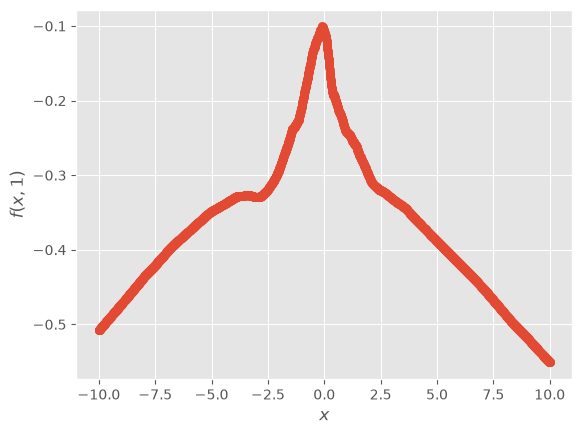

In [20]:
plt.scatter(x_grid, yb)
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x,1)$")
plt.show()

### Exercise : plot $f(x,-1.0)$, $f(x,-0.5)$, $f(x,0.0)$, $f(x,0.5)$, $f(x,1.0)$ all on the same graph

## Simple Training

In [21]:
# specify the loss function and the optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(f.parameters(), lr=0.001)

In [22]:
# training data
N = 10000
X = np.random.normal(loc = 0, scale = 1, size = (N,2))
# loc is the mean of the data
# scale is the std dev
# size is the shape of the data
print("X.shape = ", X.shape)
print("np.mean(X) = ", np.mean(X))
print("np.std(X) = ", np.std(X))

# define Y
eps = 0.1 # some random noise
Xsqrd = X**2
print(Xsqrd.shape)
Y = np.sum(Xsqrd, axis = 1) + eps * np.random.normal(0,1,N)
Y = Y.reshape(N,1) # reshape
print("Y.shape = ", Y.shape)

X.shape =  (10000, 2)
np.mean(X) =  0.010629082273549991
np.std(X) =  0.9997958309372653
(10000, 2)
Y.shape =  (10000, 1)


In [23]:
# convert numpy arrays to torch tensors
X_tensor = torch.from_numpy(X).float()
Y_tensor = torch.from_numpy(Y).float()
print("Y_tensor.shape = ", Y_tensor.shape)

N = X_tensor.shape[0]
batch_size = 100
num_epochs = 10

# training loop
for epoch in range(num_epochs):
    permutation = torch.randperm(N)
    epoch_loss = 0.0

    for i in range(0, N, batch_size):
        indices = permutation[i:i + batch_size]
        X_batch = X_tensor[indices]
        Y_batch = Y_tensor[indices]

        Y_pred = f(X_batch)
        loss = loss_fn(Y_pred, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= N
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Y_tensor.shape =  torch.Size([10000, 1])
Epoch 1/10, Loss: 1.3191
Epoch 2/10, Loss: 0.1088
Epoch 3/10, Loss: 0.0468
Epoch 4/10, Loss: 0.0288
Epoch 5/10, Loss: 0.0244
Epoch 6/10, Loss: 0.0222
Epoch 7/10, Loss: 0.0192
Epoch 8/10, Loss: 0.0178
Epoch 9/10, Loss: 0.0168
Epoch 10/10, Loss: 0.0155


Now plot the output of the trained model, as a heatmap

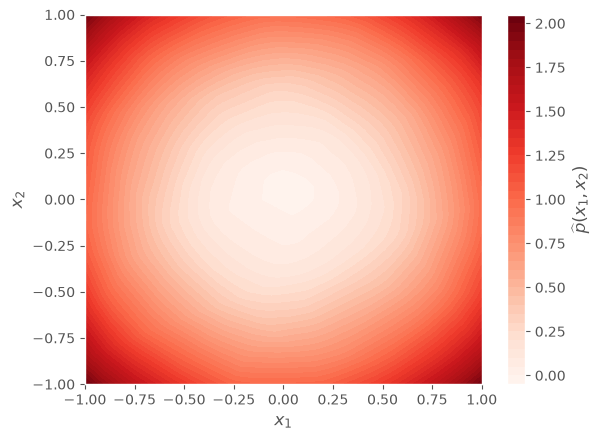

In [24]:
range = 1
grid = np.linspace(-range, range, num=1001)
X_1g, X_2g = np.meshgrid(grid, grid)

X_1gf = np.reshape(X_1g, (1001*1001, 1))
X_2gf = np.reshape(X_2g, (1001*1001, 1))
Xf = np.concatenate((X_1gf, X_2gf), 1)

# get the device the model is currently on
device = next(f.parameters()).device  

# 1. Make sure Xft is a float32 tensor
if isinstance(Xf, np.ndarray):
    Xft = torch.from_numpy(Xf).float()
else:
    Xft = Xf.float()

# 2. Make sure it's on the same device as the model
device = next(f.parameters()).device
Xft = Xft.to(device)

# 3. Set eval mode and disable gradient tracking for inference
f.eval()
with torch.no_grad():
    ppred = f(Xft)

ppred_np = ppred.cpu().numpy()
ppred_np = np.reshape(ppred_np,(1001, 1001))

plt.contourf(X_1g, X_2g, ppred_np, 50, cmap="Reds")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$\widehat{p}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()